# EV Charging Access Gap Analyzer (New York State)

this notebook is the main program for our final project. it ranks NY regions by an "EV charging access gap" score to find where charging infrastructure is most lacking.

how it works:
1. loads the NREL Alternative Fuel Stations CSV for NY
2. cleans it down to electric, operational stations
3. groups stations into `RegionProfile` objects (one per city)
4. scores every region with a weighted gap formula
5. visualizes the worst regions

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_stations, clean_stations
from src.analysis import (
    build_regions,
    rank_regions,
    underserved_regions,
    network_overlap,
    networks_only_in,
)
from src.visualize import (
    plot_top_n_underserved,
    plot_port_mix,
    plot_geographic_distribution,
)

In [4]:
# load and clean the NREL EV charging station data for NY
raw_df = load_stations("data/alt_fuel_stations.csv")
clean_df = clean_stations(raw_df)

print(f"Cleaned data shape: {clean_df.shape}")
clean_df.head()

Cleaned data shape: (5507, 14)


,station_id,fuel_type_code,station_name,city,state,zip_code,status_code,access_code,level1,level2,dc_fast,network,latitude,longitude
0,35272,ELEC,New York Institute of Technology - Old Westbur...,Old Westbury,NY,11568,E,private,4,0,0,Non-Networked,40.814019,-73.608978
1,35562,ELEC,New York State Energy Research Development Aut...,Albany,NY,12203,E,private,1,7,0,Non-Networked,42.702424,-73.857693
2,35563,ELEC,Saratoga Technology & Energy Park,Malta,NY,12020,E,private,2,0,0,Non-Networked,42.969823,-73.773021
3,36532,ELEC,Hudson Valley Community College - TEC-SMART Bu...,Malta,NY,12020,E,public,1,0,0,Non-Networked,42.971670,-73.774182
4,41240,ELEC,James J Peters VA Medical Center,Bronx,NY,10468,E,private,0,3,0,Non-Networked,40.867403,-73.906405


In [5]:
# group stations into per-city RegionProfiles
regions = build_regions(clean_df, region_col="city")
print(f"Built {len(regions)} city-level regions.\n")

# show the 3 biggest regions of RegionProfile's
biggest = sorted(regions.values(), key=lambda r: r.total_stations(), reverse=True)[:3]
for region in biggest:
    print(region)
    print("---")

Built 747 city-level regions.

RegionProfile: New York (city)
  Stations:        444
  Total ports:     2052
  Fast-capable:    16
  Public stations: 424
  Networks:        ['AMPUP', 'Blink Network', 'ChargePoint Network', 'EV Connect', 'EVOKE', 'FLASH', 'FLO', 'GRAVITY_CHARGING_CENTER', 'KWEV', 'LOOP', 'Non-Networked', 'REVEL', 'Tesla', 'Tesla Destination', 'VIALYNK']
---
RegionProfile: Rochester (city)
  Stations:        229
  Total ports:     757
  Fast-capable:    24
  Public stations: 227
  Networks:        ['CHARGESMART_EV', 'ChargePoint Network', 'EV Connect', 'EVGATEWAY', 'EVOKE', 'FLO', 'Non-Networked', 'RED_E', 'SWTCH', 'SYNERGEV', 'Tesla Destination', 'VIALYNK']
---
RegionProfile: Albany (city)
  Stations:        194
  Total ports:     656
  Fast-capable:    14
  Public stations: 184
  Networks:        ['AMPUP', 'Blink Network', 'CHARGESMART_EV', 'ChargePoint Network', 'EV Connect', 'Electrify America', 'FLO', 'Non-Networked', 'SWTCH', 'Tesla', 'VIALYNK', 'eVgo Network']
---

In [6]:
# rank every region by gap score and show the worst 10 as a table
ranked = rank_regions(regions)
top_10 = pd.DataFrame(ranked[:10], columns=["City", "Gap Score"])
top_10

,City,Gap Score
0,Blauvelt,0.795308
1,Comstock,0.795308
2,Ronkonkoma,0.795308
3,Holmes,0.795308
4,Hawthorne,0.795308
5,Laurel Hollow,0.795308
6,Greenpoint,0.795308
7,Otisville,0.795308
8,West Bronx,0.795308
9,Cassadaga,0.795308


In [7]:
# generator demo: stream the most underserved cities one at a time.
# enumerate gives us a 1-indexed rank without materializing a full list.
print("Top 10 underserved cities (gap score > 0.7):")
for rank, (city, score) in enumerate(underserved_regions(regions, threshold=0.7), start=1):
    print(f"  #{rank:>2} {city:<25} score={score:.3f}")
    if rank >= 10:
        break

Top 10 underserved cities (gap score > 0.7):
  # 1 Blauvelt                  score=0.795
  # 2 Comstock                  score=0.795
  # 3 Ronkonkoma                score=0.795
  # 4 Holmes                    score=0.795
  # 5 Hawthorne                 score=0.795
  # 6 Laurel Hollow             score=0.795
  # 7 Greenpoint                score=0.795
  # 8 Otisville                 score=0.795
  # 9 West Bronx                score=0.795
  #10 Elmsford                  score=0.738


In [8]:
# set-ops demo: compare the charging-network rosters of the two
# cities with the most stations
city_a, city_b = biggest[0], biggest[1]

print(f"Comparing networks: '{city_a.region_name}' vs '{city_b.region_name}'\n")
print(f"  Networks in both:        {sorted(network_overlap(city_a, city_b))}")
print(f"  Only in {city_a.region_name}: {sorted(networks_only_in(city_a, city_b))}")
print(f"  Only in {city_b.region_name}: {sorted(networks_only_in(city_b, city_a))}")

Comparing networks: 'New York' vs 'Rochester'

  Networks in both:        ['ChargePoint Network', 'EV Connect', 'EVOKE', 'FLO', 'Non-Networked', 'Tesla Destination', 'VIALYNK']
  Only in New York: ['AMPUP', 'Blink Network', 'FLASH', 'GRAVITY_CHARGING_CENTER', 'KWEV', 'LOOP', 'REVEL', 'Tesla']
  Only in Rochester: ['CHARGESMART_EV', 'EVGATEWAY', 'RED_E', 'SWTCH', 'SYNERGEV']


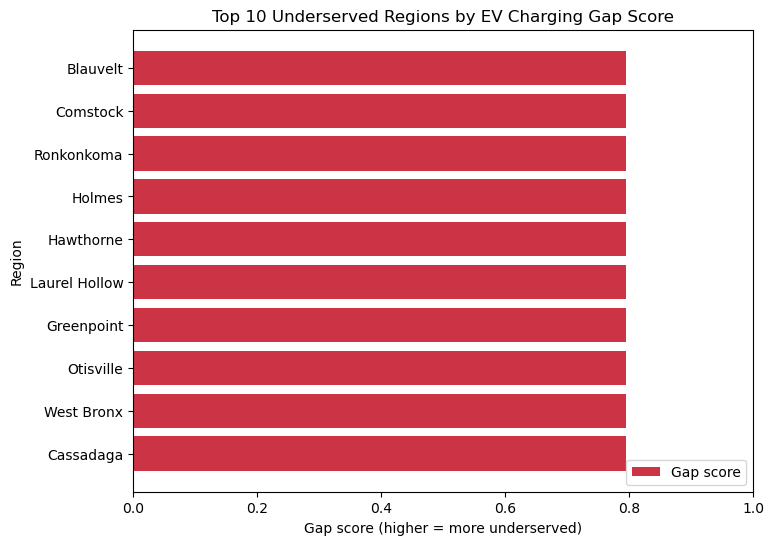

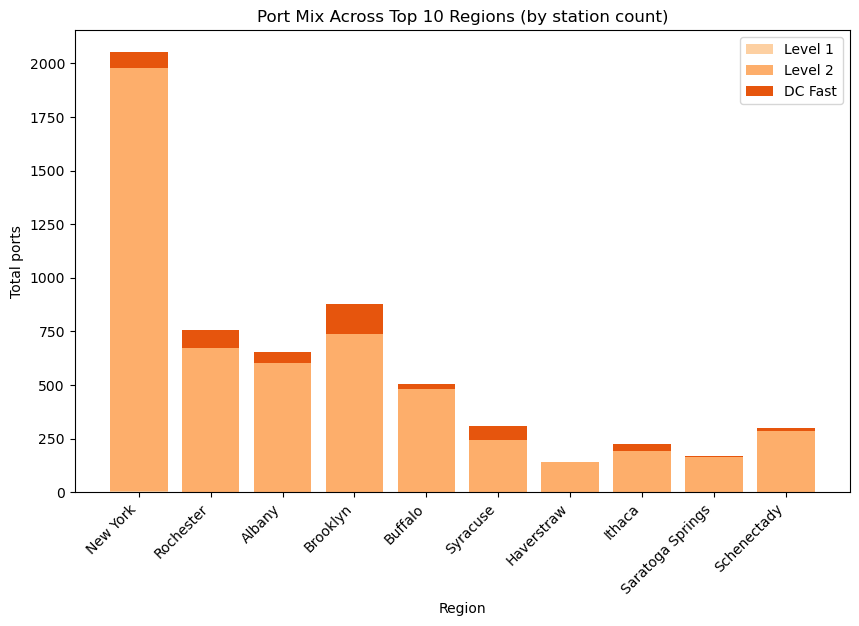

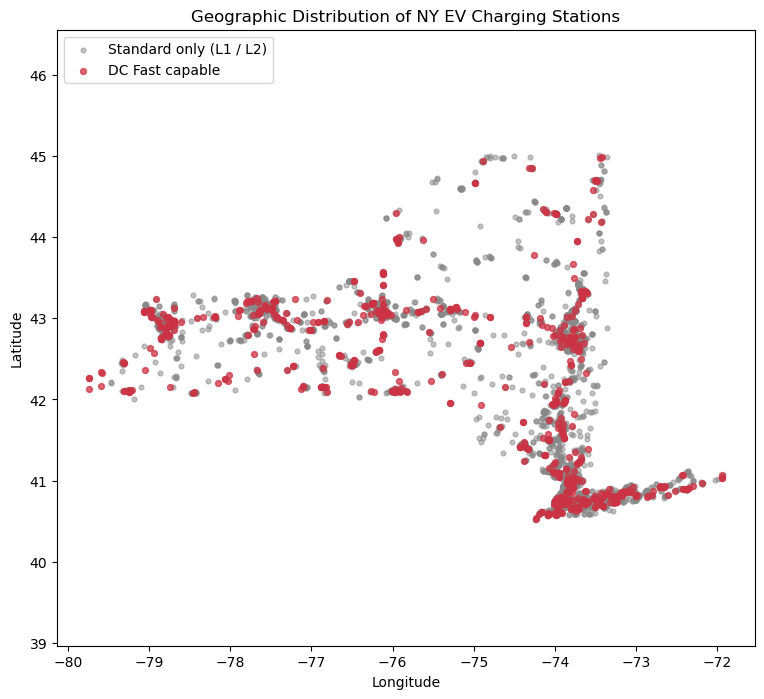

In [9]:
# visualize the analysis: top underserved regions, port mix, and geographic spread
plot_top_n_underserved(ranked, n=10)
plot_port_mix(regions, n=10)
plot_geographic_distribution(clean_df)
plt.show()

## Conclusion

the cities at the top of the chart have the highest gap scores, meaning they are the most underserved by current EV charging infrastructure in New York.

an investor or planner deciding where to deploy new chargers should start with these regions: the combination of low station counts, few DC Fast options, and limited public access leaves drivers in those cities with the worst experience today.